Analyzing images — please wait...

  Loading Image 1 ...
  Loading Image 2 ...

  IMAGE QUALITY ANALYSIS REPORT

  [HIGH QUALITY]  Image 1
  ────────────────────────────────────────────
  Overall Score      : 96.5 / 100
  Resolution         : 1800 x 1200 px  (2.16 MP)
  Sharpness          : 151.3   (higher = sharper)
  Noise Level        : 0.78   (lower = cleaner)
  Contrast (RMS)     : 61.8
  Brightness         : 120.1 / 255
  Saturation         : 113.5 / 255
  JPEG Artifacts     : 0.44   (lower = fewer)

  [LOW QUALITY]  Image 2
  ────────────────────────────────────────────
  Overall Score      : 33.5 / 100
  Resolution         : 120 x 80 px  (0.0096 MP)
  Sharpness          : 38.5   (higher = sharper)
  Noise Level        : 5.96   (lower = cleaner)
  Contrast (RMS)     : 63.0
  Brightness         : 120.3 / 255
  Saturation         : 115.0 / 255
  JPEG Artifacts     : 3.30   (lower = fewer)

  VERDICT  :  Image 1 is the HIGHER quality image
  Margin   :  63.0 point difference



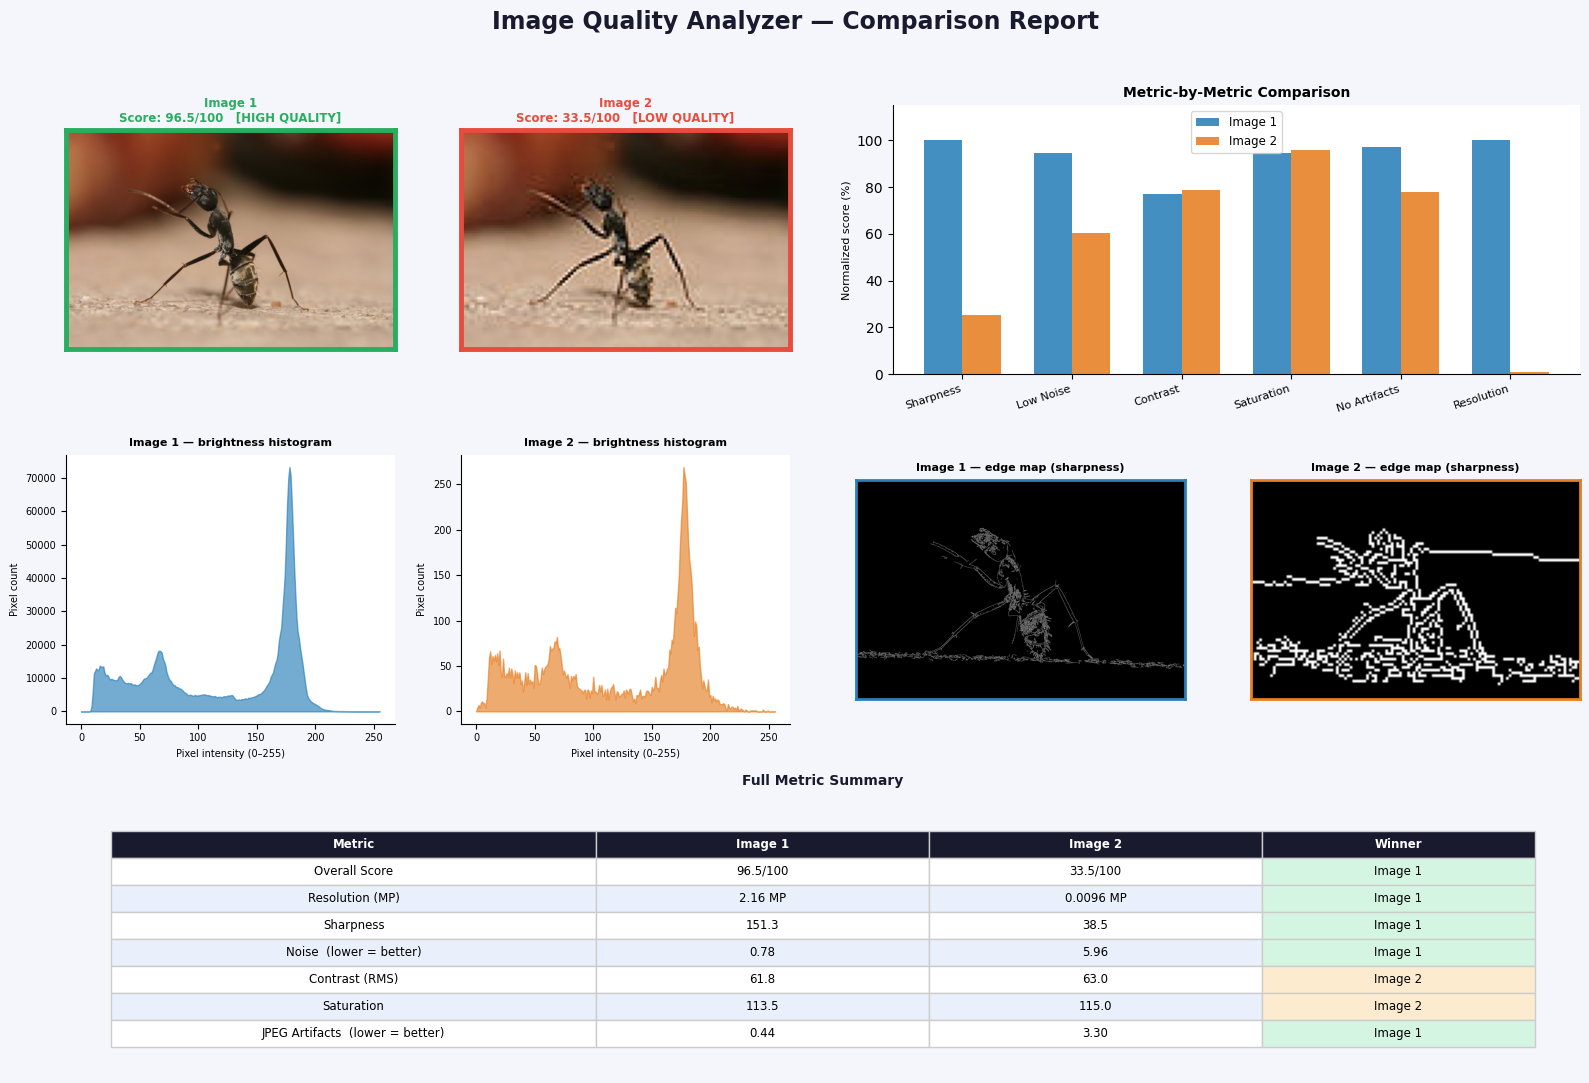

  Report also saved as  quality_report.png


In [ ]:
# ============================================================
#  IMAGE QUALITY ANALYZER — Google Colab
#  Paste two image URLs and this tool will analyze which is
#  high quality vs low quality using computer vision metrics.
#
#  HOW TO USE:
#  1. Upload this file to Google Colab (File > Upload notebook
#     OR paste code into cells manually)
#  2. Run Cell 1 to install dependencies
#  3. Run Cell 2 to import libraries
#  4. Run Cell 3 to define all functions
#  5. In Cell 4, replace the two URLs with your own image URLs
#  6. Run Cell 4 to see the full analysis report
# ============================================================


# ── CELL 1: Install dependencies ──────────────────────────
# Run this cell first (only needed once per Colab session)

# !pip install requests Pillow numpy opencv-python-headless matplotlib --quiet


# ── CELL 2: Import libraries ──────────────────────────────

import requests
import numpy as np
import cv2
import matplotlib.pyplot as plt
from io import BytesIO


# ── CELL 3: Define all analysis functions ─────────────────

def load_image_from_url(url: str) -> np.ndarray:
    """Download an image from a URL and return it as a NumPy array (BGR)."""
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=15)
    response.raise_for_status()
    img_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not decode image from URL:\n  {url}")
    return img


def calc_sharpness_density(gray: np.ndarray) -> float:
    """
    Sharpness density = Laplacian variance per pixel area.
    Normalising by pixel count prevents small/downsampled images from
    appearing artificially sharp — a 120px thumbnail should not beat a
    full-resolution image just because its few pixels have high variance.
    """
    lap_var = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    pixel_count = gray.shape[0] * gray.shape[1]
    # Scale up so typical high-res images land in a useful numeric range
    return lap_var * (pixel_count / 1_000_000.0)


def calc_noise(gray: np.ndarray) -> float:
    """
    High-frequency residual noise estimate.
    Lower value = less noise = cleaner image.
    """
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    residual = cv2.absdiff(gray.astype(np.float32), blurred.astype(np.float32))
    return float(residual.mean())


def calc_contrast(gray: np.ndarray) -> float:
    """
    RMS contrast (standard deviation of pixel brightness).
    Higher = more dynamic tonal range.
    """
    return float(gray.std())


def calc_brightness(gray: np.ndarray) -> float:
    """Mean pixel brightness (0–255)."""
    return float(gray.mean())


def calc_saturation(bgr: np.ndarray) -> float:
    """
    Mean HSV saturation channel.
    Higher = more vivid, saturated colors.
    """
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    return float(hsv[:, :, 1].mean())


def calc_compression_artifacts(gray: np.ndarray) -> float:
    """
    Detect JPEG blockiness via DCT high-frequency energy.
    Lower = fewer compression artifacts = better quality.
    """
    h, w = gray.shape
    h8, w8 = (h // 8) * 8, (w // 8) * 8
    gray_crop = gray[:h8, :w8].astype(np.float32)
    scores = []
    for row in range(0, h8, 8):
        for col in range(0, w8, 8):
            block = gray_crop[row:row + 8, col:col + 8]
            dct_block = cv2.dct(block)
            high_freq = dct_block[4:, 4:]
            scores.append(float(np.abs(high_freq).mean()))
    return float(np.mean(scores)) if scores else 0.0


def calc_resolution_score(img: np.ndarray) -> tuple:
    """Return (width, height, megapixels)."""
    h, w = img.shape[:2]
    mp = round((w * h) / 1_000_000, 4)
    return w, h, mp


def analyze_image(url: str, label: str) -> dict:
    """Run all quality metrics on an image loaded from a URL."""
    print(f"  Loading {label} ...")
    bgr = load_image_from_url(url)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    w, h, mp = calc_resolution_score(bgr)
    return {
        "label":      label,
        "url":        url,
        "bgr":        bgr,
        "gray":       gray,
        "width":      w,
        "height":     h,
        "megapixels": mp,
        "sharpness":  calc_sharpness_density(gray),   # density-corrected
        "noise":      calc_noise(gray),
        "contrast":   calc_contrast(gray),
        "brightness": calc_brightness(gray),
        "saturation": calc_saturation(bgr),
        "artifacts":  calc_compression_artifacts(gray),
    }


def compute_score(m: dict, max_sharpness: float, max_mp: float) -> float:
    """
    Composite quality score (0–100).

    Scores are normalised RELATIVE to the two images being compared so
    that the scale adapts to whatever resolution range is present.
    This prevents a small thumbnail from ever beating a full-res image
    on resolution or density-adjusted sharpness.

    Weights:
      Resolution      35% — pixel count is the single clearest proxy for
                            original vs compressed/downscaled
      Sharpness       30% — density-adjusted edge clarity
      Noise           15% — grain / blur residual
      Contrast        10% — tonal dynamic range
      Saturation       5% — color richness
      Artifacts        5% — JPEG blockiness
    """
    # Normalise resolution on a log scale so a 2× size difference is
    # clearly rewarded without a 100× difference dominating everything
    resolution_score = min(np.log1p(m["megapixels"]) / np.log1p(max(max_mp, 0.001)), 1.0)

    # Sharpness: relative to the sharper of the two images
    sharpness_score  = min(m["sharpness"] / max(max_sharpness, 0.001), 1.0)

    # Noise: lower is better — use a gentler cap so real differences show
    noise_score      = max(1.0 - m["noise"] / 15.0, 0.0)

    # Contrast: typical std dev range 20–80 for natural images
    contrast_score   = min(m["contrast"] / 80.0, 1.0)

    # Saturation
    saturation_score = min(m["saturation"] / 120.0, 1.0)

    # Artifacts: lower is better
    artifact_score   = max(1.0 - m["artifacts"] / 15.0, 0.0)

    composite = (
        resolution_score * 0.35 +
        sharpness_score  * 0.30 +
        noise_score      * 0.15 +
        contrast_score   * 0.10 +
        saturation_score * 0.05 +
        artifact_score   * 0.05
    )
    return round(composite * 100, 1)


def winner_label(v1, v2, label1, label2, lower_is_better=False):
    """Return the winner label for a given metric."""
    if lower_is_better:
        if v1 < v2: return label1
        if v2 < v1: return label2
    else:
        if v1 > v2: return label1
        if v2 > v1: return label2
    return "Tie"


def display_results(img1: dict, img2: dict):
    """Print a formatted comparison report and render a visual dashboard."""

    # Relative normalization: scale both scores against the same reference
    max_mp        = max(img1["megapixels"], img2["megapixels"])
    max_sharpness = max(img1["sharpness"],  img2["sharpness"])

    s1 = compute_score(img1, max_sharpness, max_mp)
    s2 = compute_score(img2, max_sharpness, max_mp)

    if s1 > s2:
        hq, lq = img1, img2
    elif s2 > s1:
        hq, lq = img2, img1
    else:
        hq = lq = None  # tie

    def tag(m):
        if hq is None: return "SAME QUALITY"
        return "HIGH QUALITY" if m is hq else "LOW QUALITY"

    # ── Text report ──────────────────────────────────────
    print("\n" + "=" * 62)
    print("  IMAGE QUALITY ANALYSIS REPORT")
    print("=" * 62)
    for m, s in [(img1, s1), (img2, s2)]:
        print(f"\n  [{tag(m)}]  {m['label']}")
        print(f"  {'─' * 44}")
        print(f"  Overall Score      : {s} / 100")
        print(f"  Resolution         : {m['width']} x {m['height']} px  ({m['megapixels']} MP)")
        print(f"  Sharpness          : {m['sharpness']:.1f}   (higher = sharper)")
        print(f"  Noise Level        : {m['noise']:.2f}   (lower = cleaner)")
        print(f"  Contrast (RMS)     : {m['contrast']:.1f}")
        print(f"  Brightness         : {m['brightness']:.1f} / 255")
        print(f"  Saturation         : {m['saturation']:.1f} / 255")
        print(f"  JPEG Artifacts     : {m['artifacts']:.2f}   (lower = fewer)")

    print("\n" + "=" * 62)
    if hq is not None:
        print(f"  VERDICT  :  {hq['label']} is the HIGHER quality image")
        print(f"  Margin   :  {abs(s1 - s2):.1f} point difference")
    else:
        print("  VERDICT  :  Both images appear to have equal quality")
    print("=" * 62 + "\n")

    # ── Visual dashboard ─────────────────────────────────
    fig = plt.figure(figsize=(16, 11))
    fig.patch.set_facecolor("#f4f6fb")
    fig.suptitle("Image Quality Analyzer — Comparison Report",
                 fontsize=17, fontweight="bold", color="#1a1a2e", y=0.98)

    color1 = "#2980b9"
    color2 = "#e67e22"
    hq_color = "#27ae60"
    lq_color = "#e74c3c"

    def border_color(m):
        if hq is None: return "#7f8c8d"
        return hq_color if m is hq else lq_color

    # ── Row 1: Images ────────────────────────────────────
    ax_img1 = fig.add_subplot(3, 4, 1)
    ax_img2 = fig.add_subplot(3, 4, 2)
    for ax, m, s in [(ax_img1, img1, s1), (ax_img2, img2, s2)]:
        rgb = cv2.cvtColor(m["bgr"], cv2.COLOR_BGR2RGB)
        ax.imshow(rgb)
        bc = border_color(m)
        for spine in ax.spines.values():
            spine.set_edgecolor(bc)
            spine.set_linewidth(3.5)
        ax.set_title(f"{m['label']}\nScore: {s}/100   [{tag(m)}]",
                     fontsize=8.5, fontweight="bold", color=bc)
        ax.set_xticks([])
        ax.set_yticks([])

    # ── Row 1: Metric bar chart ──────────────────────────
    ax_bar = fig.add_subplot(3, 2, 2)
    metric_names = ["Sharpness", "Low Noise", "Contrast",
                    "Saturation", "No Artifacts", "Resolution"]

    def norm_vals(m):
        return [
            min(m["sharpness"]  / max(max_sharpness, 0.001), 1.0) * 100,  # relative
            max(1.0 - m["noise"] / 15.0, 0.0) * 100,
            min(m["contrast"]   / 80.0,  1.0) * 100,
            min(m["saturation"] / 120.0, 1.0) * 100,
            max(1.0 - m["artifacts"] / 15.0, 0.0) * 100,
            min(np.log1p(m["megapixels"]) / np.log1p(max(max_mp, 0.001)), 1.0) * 100,  # log-relative
        ]

    v1 = norm_vals(img1)
    v2 = norm_vals(img2)
    x = np.arange(len(metric_names))
    w = 0.35
    ax_bar.bar(x - w/2, v1, w, label=img1["label"], color=color1, alpha=0.88)
    ax_bar.bar(x + w/2, v2, w, label=img2["label"], color=color2, alpha=0.88)
    ax_bar.set_ylim(0, 115)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(metric_names, fontsize=8, rotation=18, ha="right")
    ax_bar.set_ylabel("Normalized score (%)", fontsize=8)
    ax_bar.set_title("Metric-by-Metric Comparison", fontsize=10, fontweight="bold")
    ax_bar.legend(fontsize=8.5)
    ax_bar.set_facecolor("#ffffff")
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)

    # ── Row 2: Histograms ────────────────────────────────
    for i, (m, col) in enumerate([(img1, color1), (img2, color2)]):
        ax_h = fig.add_subplot(3, 4, 5 + i)
        hist = cv2.calcHist([m["gray"]], [0], None, [256], [0, 256])
        ax_h.fill_between(range(256), hist[:, 0], alpha=0.65, color=col)
        ax_h.set_title(f"{m['label']} — brightness histogram",
                       fontsize=8, fontweight="bold")
        ax_h.set_xlabel("Pixel intensity (0–255)", fontsize=7)
        ax_h.set_ylabel("Pixel count", fontsize=7)
        ax_h.tick_params(labelsize=7)
        ax_h.set_facecolor("#ffffff")
        ax_h.spines["top"].set_visible(False)
        ax_h.spines["right"].set_visible(False)

    # ── Row 2: Edge maps ─────────────────────────────────
    for i, (m, col) in enumerate([(img1, color1), (img2, color2)]):
        ax_e = fig.add_subplot(3, 4, 7 + i)
        edges = cv2.Canny(m["gray"], 50, 150)
        ax_e.imshow(edges, cmap="gray")
        ax_e.set_title(f"{m['label']} — edge map (sharpness)",
                       fontsize=8, fontweight="bold")
        ax_e.set_xticks([])
        ax_e.set_yticks([])
        for spine in ax_e.spines.values():
            spine.set_edgecolor(col)
            spine.set_linewidth(2)

    # ── Row 3: Summary table ─────────────────────────────
    ax_tbl = fig.add_subplot(3, 1, 3)
    ax_tbl.axis("off")

    rows = [
        ["Overall Score",
         f"{s1}/100", f"{s2}/100",
         winner_label(s1, s2, img1["label"], img2["label"])],
        ["Resolution (MP)",
         f"{img1['megapixels']} MP", f"{img2['megapixels']} MP",
         winner_label(img1["megapixels"], img2["megapixels"],
                      img1["label"], img2["label"])],
        ["Sharpness",
         f"{img1['sharpness']:.1f}", f"{img2['sharpness']:.1f}",
         winner_label(img1["sharpness"], img2["sharpness"],
                      img1["label"], img2["label"])],
        ["Noise  (lower = better)",
         f"{img1['noise']:.2f}", f"{img2['noise']:.2f}",
         winner_label(img1["noise"], img2["noise"],
                      img1["label"], img2["label"], lower_is_better=True)],
        ["Contrast (RMS)",
         f"{img1['contrast']:.1f}", f"{img2['contrast']:.1f}",
         winner_label(img1["contrast"], img2["contrast"],
                      img1["label"], img2["label"])],
        ["Saturation",
         f"{img1['saturation']:.1f}", f"{img2['saturation']:.1f}",
         winner_label(img1["saturation"], img2["saturation"],
                      img1["label"], img2["label"])],
        ["JPEG Artifacts  (lower = better)",
         f"{img1['artifacts']:.2f}", f"{img2['artifacts']:.2f}",
         winner_label(img1["artifacts"], img2["artifacts"],
                      img1["label"], img2["label"], lower_is_better=True)],
    ]
    col_labels = ["Metric", img1["label"], img2["label"], "Winner"]
    col_widths  = [0.32, 0.22, 0.22, 0.18]

    tbl = ax_tbl.table(
        cellText=rows,
        colLabels=col_labels,
        cellLoc="center",
        loc="center",
        colWidths=col_widths,
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 1.5)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor("#cccccc")
        if row == 0:
            cell.set_facecolor("#1a1a2e")
            cell.set_text_props(color="white", fontweight="bold")
        elif col == 3 and row > 0:
            txt = cell.get_text().get_text()
            if txt == img1["label"]:
                cell.set_facecolor("#d5f5e3")
            elif txt == img2["label"]:
                cell.set_facecolor("#fdebd0")
            else:
                cell.set_facecolor("#f0f0f0")
        elif row % 2 == 0:
            cell.set_facecolor("#eaf0fb")
        else:
            cell.set_facecolor("#ffffff")

    ax_tbl.set_title("Full Metric Summary", fontsize=10,
                     fontweight="bold", pad=14, color="#1a1a2e")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig("quality_report.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("  Report also saved as  quality_report.png")


# ── CELL 4: ▶ ENTER YOUR IMAGE URLS HERE THEN RUN ─────────
# ─────────────────────────────────────────────────────────
#
#  Replace the example URLs below with direct links to any
#  two images on the web.  No images are downloaded to your
#  local machine — they are fetched only inside Colab.
#
#  Tip: right-click any image in Chrome and choose
#       "Copy image address" to get a direct URL.
#
#  Supported formats: JPG · PNG · WebP · BMP · GIF (first frame)
#
# ─────────────────────────────────────────────────────────

IMAGE_1_URL   = "https://upload.wikimedia.org/wikipedia/commons/a/a7/Camponotus_flavomarginatus_ant.jpg"
IMAGE_1_LABEL = "Image 1"

IMAGE_2_URL   = "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/120px-Camponotus_flavomarginatus_ant.jpg"
IMAGE_2_LABEL = "Image 2"

# ─────────────────────────────────────────────────────────
print("Analyzing images — please wait...\n")

try:
    metrics1 = analyze_image(IMAGE_1_URL, IMAGE_1_LABEL)
    metrics2 = analyze_image(IMAGE_2_URL, IMAGE_2_LABEL)
    display_results(metrics1, metrics2)
except requests.exceptions.HTTPError as e:
    print(f"HTTP error fetching image: {e}")
    print("Make sure both URLs are publicly accessible direct image links.")
except requests.exceptions.RequestException as e:
    print(f"Network error: {e}")
except ValueError as e:
    print(f"Image decode error: {e}")
    print("Ensure the URLs point directly to image files (not HTML pages).")
except Exception as e:
    print(f"Unexpected error: {type(e).__name__}: {e}")